In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

In [2]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.titleweight": "bold",
    "axes.labelsize": 18,
    "axes.labelweight": "bold",
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "figure.titlesize": 22
})

In [3]:
DATA_PATH = Path("features/features_dataset_completed.csv")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 103
Columns: 43


,Trial_ID,Trial_Name,Task,Subject,Repetition,Frames,Duration_Seconds,Self_Proclaimed_Skill,GRS_Total,GRS_Tissue_Respect,GRS_Handling,GRS_Time_Motion,GRS_Flow,GRS_Performance,GRS_Quality,Left_Mean_Speed,Left_Median_Speed,Left_Max_Speed,Left_Speed_Std,Right_Mean_Speed,Right_Median_Speed,Right_Max_Speed,Right_Speed_Std,Left_Idle_Ratio,Left_Idle_Time,Right_Idle_Ratio,Right_Idle_Time,Left_Mean_Acceleration,Left_Median_Acceleration,Left_Max_Acceleration,Left_Acceleration_Std,Right_Mean_Acceleration,Right_Median_Acceleration,Right_Max_Acceleration,Right_Acceleration_Std,Left_Mean_Jerk,Left_Median_Jerk,Left_Max_Jerk,Left_Jerk_Std,Right_Mean_Jerk,Right_Median_Jerk,Right_Max_Jerk,Right_Jerk_Std
0,1,Knot_Tying_B001,Knot Tying,B,1,1735.0,57.833333,N,13,2,2,2,2,2,3,0.014951,0.013207,0.087311,0.015546,0.020190,0.015791,0.112647,0.015746,0.222478,12.866667,0.070317,4.066667,0.146096,0.056879,0.847640,0.165340,0.170213,0.108588,0.843541,0.167266,7.622136,5.682701,36.873741,7.453799,8.593367,7.073302,40.353393,7.335405
1,2,Knot_Tying_B002,Knot Tying,B,2,1480.0,49.333333,N,9,1,1,2,2,1,2,0.016084,0.012020,0.102001,0.019280,0.017183,0.013839,0.120919,0.016700,0.260811,12.866667,0.213514,10.533333,0.128396,0.042267,0.934575,0.157012,0.144601,0.065168,0.973320,0.164648,6.723691,4.527618,42.726024,7.146354,7.542256,5.485829,37.436082,7.511898
2,3,Knot_Tying_B003,Knot Tying,B,3,1612.0,53.733333,N,11,1,2,2,2,2,2,0.016374,0.006430,0.122372,0.022933,0.020801,0.015218,0.104930,0.019657,0.330645,17.766667,0.158809,8.533333,0.125723,0.037879,0.842469,0.158248,0.150946,0.084019,1.023193,0.161790,6.460709,2.728039,33.766569,7.211879,7.579566,5.951247,34.233631,7.048546
3,4,Knot_Tying_B004,Knot Tying,B,4,1820.0,60.666667,N,8,1,2,1,1,1,2,0.024496,0.016678,0.148949,0.025358,0.021769,0.016691,0.122552,0.020269,0.137363,8.333333,0.121429,7.366667,0.168501,0.091581,1.898380,0.186236,0.160645,0.083615,1.133113,0.170254,8.362984,6.784780,86.717686,8.121838,8.006840,6.189190,42.715483,7.500375
4,5,Knot_Tying_C001,Knot Tying,C,1,1227.0,40.900000,I,20,4,3,3,3,3,4,0.039064,0.023910,0.206086,0.041256,0.031764,0.020429,0.182760,0.033936,0.127139,5.200000,0.088835,3.633333,0.235873,0.166642,1.559769,0.244696,0.245540,0.184320,1.947408,0.242559,10.661945,9.530731,82.891074,9.528750,11.136463,9.359178,91.332887,9.958655


In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate Trial_ID values:")
print(df["Trial_ID"].duplicated().sum())

print("\nTrials per task:")
print(df["Task"].value_counts())

print("\nTrials per subject:")
print(df["Subject"].value_counts().sort_index())

Dataset shape: (103, 43)

Column names:
['Trial_ID', 'Trial_Name', 'Task', 'Subject', 'Repetition', 'Frames', 'Duration_Seconds', 'Self_Proclaimed_Skill', 'GRS_Total', 'GRS_Tissue_Respect', 'GRS_Handling', 'GRS_Time_Motion', 'GRS_Flow', 'GRS_Performance', 'GRS_Quality', 'Left_Mean_Speed', 'Left_Median_Speed', 'Left_Max_Speed', 'Left_Speed_Std', 'Right_Mean_Speed', 'Right_Median_Speed', 'Right_Max_Speed', 'Right_Speed_Std', 'Left_Idle_Ratio', 'Left_Idle_Time', 'Right_Idle_Ratio', 'Right_Idle_Time', 'Left_Mean_Acceleration', 'Left_Median_Acceleration', 'Left_Max_Acceleration', 'Left_Acceleration_Std', 'Right_Mean_Acceleration', 'Right_Median_Acceleration', 'Right_Max_Acceleration', 'Right_Acceleration_Std', 'Left_Mean_Jerk', 'Left_Median_Jerk', 'Left_Max_Jerk', 'Left_Jerk_Std', 'Right_Mean_Jerk', 'Right_Median_Jerk', 'Right_Max_Jerk', 'Right_Jerk_Std']

Missing values:
Trial_ID                     0
Right_Median_Acceleration    0
Left_Idle_Time               0
Right_Idle_Ratio           

In [5]:
target_column = "GRS_Total"

print(df[target_column].describe())

print("\nMinimum GRS:", df[target_column].min())
print("Maximum GRS:", df[target_column].max())
print("Unique GRS values:", sorted(df[target_column].unique()))

count    103.000000
mean      16.165049
std        5.601290
min        6.000000
25%       12.000000
50%       17.000000
75%       20.000000
max       30.000000
Name: GRS_Total, dtype: float64

Minimum GRS: 6
Maximum GRS: 30
Unique GRS values: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 29, 30]


In [6]:
target_column = "GRS_Total"
group_column = "Subject"

grs_columns = [
    "GRS_Total",
    "GRS_Tissue_Respect",
    "GRS_Handling",
    "GRS_Time_Motion",
    "GRS_Flow",
    "GRS_Performance",
    "GRS_Quality",
]

metadata_columns = [
    "Trial_ID",
    "Trial_Name",
    "Task",
    "Subject",
    "Repetition",
    "Self_Proclaimed_Skill",
    "Frames",
]

excluded_columns = grs_columns + metadata_columns

feature_columns = [
    column
    for column in df.columns
    if column not in excluded_columns
]

X = df[feature_columns].copy()
y = df[target_column].copy()
groups = df[group_column].copy()

print("Number of predictors:", X.shape[1])
print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget shape:", y.shape)
print("Number of subjects:", groups.nunique())

Number of predictors: 29

Predictor columns:
['Duration_Seconds', 'Left_Mean_Speed', 'Left_Median_Speed', 'Left_Max_Speed', 'Left_Speed_Std', 'Right_Mean_Speed', 'Right_Median_Speed', 'Right_Max_Speed', 'Right_Speed_Std', 'Left_Idle_Ratio', 'Left_Idle_Time', 'Right_Idle_Ratio', 'Right_Idle_Time', 'Left_Mean_Acceleration', 'Left_Median_Acceleration', 'Left_Max_Acceleration', 'Left_Acceleration_Std', 'Right_Mean_Acceleration', 'Right_Median_Acceleration', 'Right_Max_Acceleration', 'Right_Acceleration_Std', 'Left_Mean_Jerk', 'Left_Median_Jerk', 'Left_Max_Jerk', 'Left_Jerk_Std', 'Right_Mean_Jerk', 'Right_Median_Jerk', 'Right_Max_Jerk', 'Right_Jerk_Std']

Target shape: (103,)
Number of subjects: 8


In [7]:
non_numeric_columns = X.select_dtypes(exclude=np.number).columns.tolist()

print("Non-numeric predictor columns:", non_numeric_columns)

assert len(non_numeric_columns) == 0, (
    f"These predictor columns are not numeric: {non_numeric_columns}"
)

assert not X.isna().any().any(), "Predictor matrix contains missing values."
assert not y.isna().any(), "Target contains missing values."
assert np.isfinite(X.to_numpy()).all(), "Predictors contain infinity."
assert np.isfinite(y.to_numpy()).all(), "Target contains infinity."

print("Feature matrix passed validation.")

Non-numeric predictor columns: []
Feature matrix passed validation.


In [8]:
models = {
    "Dummy Regressor": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyRegressor(strategy="mean"))
    ]),

    "Ridge Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Elastic Net": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=0.1,
            l1_ratio=0.5,
            max_iter=10000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Support Vector Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVR(
            kernel="rbf",
            C=1.0,
            epsilon=0.1,
            gamma="scale"
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ))
    ])
}

print("Models created:")
for model_name in models:
    print("-", model_name)

Models created:
- Dummy Regressor
- Ridge Regression
- Elastic Net
- Support Vector Regression
- Random Forest
- Extra Trees
- Gradient Boosting


In [9]:
logo = LeaveOneGroupOut()

splits = list(logo.split(X, y, groups=groups))

print("Number of cross-validation folds:", len(splits))

for fold_number, (train_index, test_index) in enumerate(splits, start=1):
    training_subjects = sorted(groups.iloc[train_index].unique())
    testing_subjects = sorted(groups.iloc[test_index].unique())

    print(
        f"Fold {fold_number}: "
        f"Train subjects = {training_subjects}, "
        f"Test subject = {testing_subjects}, "
        f"Test trials = {len(test_index)}"
    )

Number of cross-validation folds: 8
Fold 1: Train subjects = ['C', 'D', 'E', 'F', 'G', 'H', 'I'], Test subject = ['B'], Test trials = 13
Fold 2: Train subjects = ['B', 'D', 'E', 'F', 'G', 'H', 'I'], Test subject = ['C'], Test trials = 15
Fold 3: Train subjects = ['B', 'C', 'E', 'F', 'G', 'H', 'I'], Test subject = ['D'], Test trials = 15
Fold 4: Train subjects = ['B', 'C', 'D', 'F', 'G', 'H', 'I'], Test subject = ['E'], Test trials = 14
Fold 5: Train subjects = ['B', 'C', 'D', 'E', 'G', 'H', 'I'], Test subject = ['F'], Test trials = 13
Fold 6: Train subjects = ['B', 'C', 'D', 'E', 'F', 'H', 'I'], Test subject = ['G'], Test trials = 10
Fold 7: Train subjects = ['B', 'C', 'D', 'E', 'F', 'G', 'I'], Test subject = ['H'], Test trials = 10
Fold 8: Train subjects = ['B', 'C', 'D', 'E', 'F', 'G', 'H'], Test subject = ['I'], Test trials = 13


In [10]:
all_predictions = []
fold_results = []

for model_name, pipeline in models.items():

    print(f"\nTraining: {model_name}")

    model_predictions = np.zeros(len(X), dtype=float)

    for fold_number, (train_index, test_index) in enumerate(
        logo.split(X, y, groups=groups),
        start=1
    ):
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        test_subject = groups.iloc[test_index].unique()[0]

        # Train only on the seven training subjects
        pipeline.fit(X_train, y_train)

        # Predict all trials from the unseen subject
        y_pred = pipeline.predict(X_test)

        # Store predictions in their original dataset positions
        model_predictions[test_index] = y_pred

        fold_mae = mean_absolute_error(y_test, y_pred)
        fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_r2 = r2_score(y_test, y_pred)

        fold_results.append({
            "Model": model_name,
            "Fold": fold_number,
            "Test_Subject": test_subject,
            "Number_of_Test_Trials": len(test_index),
            "MAE": fold_mae,
            "RMSE": fold_rmse,
            "R2": fold_r2
        })

    # Store one prediction row for every trial
    model_prediction_df = pd.DataFrame({
        "Model": model_name,
        "Trial_ID": df["Trial_ID"],
        "Trial_Name": df["Trial_Name"],
        "Task": df["Task"],
        "Subject": df["Subject"],
        "Actual_GRS": y,
        "Predicted_GRS": model_predictions
    })

    model_prediction_df["Error"] = (
        model_prediction_df["Predicted_GRS"]
        - model_prediction_df["Actual_GRS"]
    )

    model_prediction_df["Absolute_Error"] = (
        model_prediction_df["Error"].abs()
    )

    all_predictions.append(model_prediction_df)

print("\nAll models finished training.")


Training: Dummy Regressor

Training: Ridge Regression

Training: Elastic Net

Training: Support Vector Regression

Training: Random Forest

Training: Extra Trees

Training: Gradient Boosting

All models finished training.


In [11]:
fold_results_df = pd.DataFrame(fold_results)

predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

print("Fold-level results shape:", fold_results_df.shape)
print("Prediction results shape:", predictions_df.shape)

fold_results_df.head()

Fold-level results shape: (56, 7)
Prediction results shape: (721, 9)


,Model,Fold,Test_Subject,Number_of_Test_Trials,MAE,RMSE,R2
0,Dummy Regressor,1,B,13,5.146154,5.826824,-2.023113
1,Dummy Regressor,2,C,15,5.915909,6.817580,-0.110177
2,Dummy Regressor,3,D,15,3.768182,4.442652,-0.925785
3,Dummy Regressor,4,E,14,2.979936,3.268983,-0.490751
4,Dummy Regressor,5,F,13,6.628205,7.878766,-0.567643


In [12]:
overall_results = []

for model_name in models.keys():

    model_data = predictions_df[
        predictions_df["Model"] == model_name
    ]

    actual = model_data["Actual_GRS"]
    predicted = model_data["Predicted_GRS"]

    overall_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
        "Mean_Error": np.mean(predicted - actual),
        "Median_Absolute_Error": np.median(
            np.abs(predicted - actual)
        )
    })

overall_results_df = pd.DataFrame(overall_results)

overall_results_df = overall_results_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

overall_results_df

,Model,MAE,RMSE,R2,Mean_Error,Median_Absolute_Error
0,Random Forest,4.345476,5.366845,0.072959,0.082136,3.792000
1,Extra Trees,4.423573,5.463226,0.039363,-0.129282,3.886000
2,Gradient Boosting,4.749647,5.975334,-0.149173,0.224468,3.547058
3,Dummy Regressor,4.907240,5.786230,-0.077587,0.001153,4.150538
4,Support Vector Regression,4.935691,5.849158,-0.101153,-0.288383,4.478205
5,Elastic Net,5.130545,6.214282,-0.242919,0.834462,4.225780
6,Ridge Regression,5.594620,6.758197,-0.470018,0.491232,4.974201


In [13]:
dummy_mae = overall_results_df.loc[
    overall_results_df["Model"] == "Dummy Regressor",
    "MAE"
].iloc[0]

overall_results_df["MAE_Improvement_Over_Dummy"] = (
    dummy_mae - overall_results_df["MAE"]
)

overall_results_df["Percent_MAE_Improvement_Over_Dummy"] = (
    overall_results_df["MAE_Improvement_Over_Dummy"]
    / dummy_mae
    * 100
)

overall_results_df

,Model,MAE,RMSE,R2,Mean_Error,Median_Absolute_Error,MAE_Improvement_Over_Dummy,Percent_MAE_Improvement_Over_Dummy
0,Random Forest,4.345476,5.366845,0.072959,0.082136,3.792000,0.561764,11.447659
1,Extra Trees,4.423573,5.463226,0.039363,-0.129282,3.886000,0.483667,9.856192
2,Gradient Boosting,4.749647,5.975334,-0.149173,0.224468,3.547058,0.157593,3.211432
3,Dummy Regressor,4.907240,5.786230,-0.077587,0.001153,4.150538,0.000000,0.000000
4,Support Vector Regression,4.935691,5.849158,-0.101153,-0.288383,4.478205,-0.028451,-0.579774
5,Elastic Net,5.130545,6.214282,-0.242919,0.834462,4.225780,-0.223306,-4.550536
6,Ridge Regression,5.594620,6.758197,-0.470018,0.491232,4.974201,-0.687380,-14.007469


In [14]:
fold_summary_df = (
    fold_results_df
    .groupby("Model")
    .agg(
        Mean_Fold_MAE=("MAE", "mean"),
        Std_Fold_MAE=("MAE", "std"),
        Mean_Fold_RMSE=("RMSE", "mean"),
        Std_Fold_RMSE=("RMSE", "std"),
        Mean_Fold_R2=("R2", "mean"),
        Std_Fold_R2=("R2", "std")
    )
    .reset_index()
    .sort_values("Mean_Fold_MAE")
)

fold_summary_df

,Model,Mean_Fold_MAE,Std_Fold_MAE,Mean_Fold_RMSE,Std_Fold_RMSE,Mean_Fold_R2,Std_Fold_R2
4,Random Forest,4.365593,0.834955,5.293601,0.920204,-0.618187,0.907116
2,Extra Trees,4.423740,1.105114,5.316400,1.197502,-0.603912,0.904290
3,Gradient Boosting,4.741910,1.162806,5.822773,1.313861,-0.853799,0.853399
0,Dummy Regressor,4.929908,1.176535,5.629447,1.431942,-0.662545,0.631577
6,Support Vector Regression,4.934626,0.933913,5.736302,1.082939,-0.844202,0.801290
1,Elastic Net,5.101040,1.676010,5.864735,1.878943,-0.789302,0.646165
5,Ridge Regression,5.592903,1.399953,6.513549,1.644528,-1.299661,0.942298


In [15]:
RESULTS_PATH = Path("results/modeling")
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

overall_results_df.to_csv(
    RESULTS_PATH / "overall_model_results.csv",
    index=False
)

fold_results_df.to_csv(
    RESULTS_PATH / "subject_fold_results.csv",
    index=False
)

fold_summary_df.to_csv(
    RESULTS_PATH / "fold_summary_results.csv",
    index=False
)

predictions_df.to_csv(
    RESULTS_PATH / "out_of_fold_predictions.csv",
    index=False
)

print("Results saved to:", RESULTS_PATH.resolve())

Results saved to: /Users/abdurrahmanoyediran/Library/CloudStorage/OneDrive-Personal(2)/Documents/02_Research/HUMANS_MOVE_RESEARCH/JIGSAWS DATA/results/modeling


In [16]:
from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV

In [17]:
models_to_tune = {
    "Random Forest": clone(models["Random Forest"]),
    "Extra Trees": clone(models["Extra Trees"]),
    "Gradient Boosting": clone(models["Gradient Boosting"]),
    "Support Vector Regression": clone(
        models["Support Vector Regression"]
    )
}

print("Models selected for tuning:")

for model_name in models_to_tune:
    print("-", model_name)

Models selected for tuning:
- Random Forest
- Extra Trees
- Gradient Boosting
- Support Vector Regression


In [18]:
parameter_spaces = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 500, 700],
        "model__max_depth": [None, 3, 5, 8, 12],
        "model__min_samples_split": [2, 4, 6, 8],
        "model__min_samples_leaf": [1, 2, 3, 4],
        "model__max_features": [
            "sqrt",
            0.5,
            0.75,
            1.0
        ],
        "model__bootstrap": [True, False]
    },

    "Extra Trees": {
        "model__n_estimators": [200, 300, 500, 700],
        "model__max_depth": [None, 3, 5, 8, 12],
        "model__min_samples_split": [2, 4, 6, 8],
        "model__min_samples_leaf": [1, 2, 3, 4],
        "model__max_features": [
            "sqrt",
            0.5,
            0.75,
            1.0
        ],
        "model__bootstrap": [True, False]
    },

    "Gradient Boosting": {
        "model__n_estimators": [50, 100, 150, 200, 300],
        "model__learning_rate": [
            0.01,
            0.03,
            0.05,
            0.1,
            0.2
        ],
        "model__max_depth": [1, 2, 3, 4],
        "model__min_samples_split": [2, 4, 6, 8],
        "model__min_samples_leaf": [1, 2, 3, 4],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__max_features": [
            None,
            "sqrt",
            0.5,
            0.75
        ]
    },

    "Support Vector Regression": {
        "model__kernel": ["rbf"],
        "model__C": [
            0.1,
            0.5,
            1,
            2,
            5,
            10,
            25,
            50,
            100
        ],
        "model__epsilon": [
            0.01,
            0.05,
            0.1,
            0.25,
            0.5,
            1.0
        ],
        "model__gamma": [
            "scale",
            "auto",
            0.001,
            0.005,
            0.01,
            0.05,
            0.1
        ]
    }
}

In [19]:
def nested_subject_tuning(
    model_name,
    estimator,
    parameter_space,
    X,
    y,
    groups,
    trial_information,
    n_iter=15
):
    """
    Tune and evaluate one model using nested
    leave-one-subject-out cross-validation.

    Outer loop:
        Measures final performance on an unseen subject.

    Inner loop:
        Selects hyperparameters using only the remaining subjects.
    """

    outer_cv = LeaveOneGroupOut()

    prediction_rows = []
    fold_rows = []
    parameter_rows = []

    print("=" * 70)
    print(f"Nested tuning: {model_name}")
    print("=" * 70)

    for outer_fold, (train_index, test_index) in enumerate(
        outer_cv.split(X, y, groups=groups),
        start=1
    ):
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        groups_train = groups.iloc[train_index]
        test_subject = groups.iloc[test_index].unique()[0]

        # Inner leave-one-subject-out validation
        inner_cv = LeaveOneGroupOut()

        search = RandomizedSearchCV(
            estimator=clone(estimator),
            param_distributions=parameter_space,
            n_iter=n_iter,
            scoring="neg_mean_absolute_error",
            cv=inner_cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
            return_train_score=False
        )

        # Groups are provided only for inner validation.
        search.fit(
            X_train,
            y_train,
            groups=groups_train
        )

        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test)

        fold_mae = mean_absolute_error(y_test, y_pred)
        fold_rmse = np.sqrt(
            mean_squared_error(y_test, y_pred)
        )
        fold_r2 = r2_score(y_test, y_pred)

        print(
            f"Outer fold {outer_fold}/8 | "
            f"Test subject: {test_subject} | "
            f"MAE: {fold_mae:.3f} | "
            f"Best inner MAE: {-search.best_score_:.3f}"
        )

        fold_rows.append({
            "Model": model_name,
            "Outer_Fold": outer_fold,
            "Test_Subject": test_subject,
            "Number_of_Test_Trials": len(test_index),
            "MAE": fold_mae,
            "RMSE": fold_rmse,
            "R2": fold_r2,
            "Best_Inner_MAE": -search.best_score_
        })

        parameter_row = {
            "Model": model_name,
            "Outer_Fold": outer_fold,
            "Test_Subject": test_subject
        }

        parameter_row.update(search.best_params_)
        parameter_rows.append(parameter_row)

        for position, dataset_index in enumerate(test_index):
            prediction_rows.append({
                "Model": model_name,
                "Outer_Fold": outer_fold,
                "Trial_ID": trial_information.iloc[
                    dataset_index
                ]["Trial_ID"],
                "Trial_Name": trial_information.iloc[
                    dataset_index
                ]["Trial_Name"],
                "Task": trial_information.iloc[
                    dataset_index
                ]["Task"],
                "Subject": trial_information.iloc[
                    dataset_index
                ]["Subject"],
                "Actual_GRS": y_test.iloc[position],
                "Predicted_GRS": y_pred[position],
                "Error": (
                    y_pred[position]
                    - y_test.iloc[position]
                ),
                "Absolute_Error": abs(
                    y_pred[position]
                    - y_test.iloc[position]
                )
            })

    predictions = pd.DataFrame(prediction_rows)
    fold_results = pd.DataFrame(fold_rows)
    selected_parameters = pd.DataFrame(parameter_rows)

    overall_results = {
        "Model": model_name,
        "MAE": mean_absolute_error(
            predictions["Actual_GRS"],
            predictions["Predicted_GRS"]
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                predictions["Actual_GRS"],
                predictions["Predicted_GRS"]
            )
        ),
        "R2": r2_score(
            predictions["Actual_GRS"],
            predictions["Predicted_GRS"]
        ),
        "Mean_Error": predictions["Error"].mean(),
        "Median_Absolute_Error": (
            predictions["Absolute_Error"].median()
        )
    }

    return {
        "overall": overall_results,
        "folds": fold_results,
        "predictions": predictions,
        "parameters": selected_parameters
    }

In [20]:
trial_information = df[
    [
        "Trial_ID",
        "Trial_Name",
        "Task",
        "Subject"
    ]
].reset_index(drop=True)

trial_information.head()

,Trial_ID,Trial_Name,Task,Subject
0,1,Knot_Tying_B001,Knot Tying,B
1,2,Knot_Tying_B002,Knot Tying,B
2,3,Knot_Tying_B003,Knot Tying,B
3,4,Knot_Tying_B004,Knot Tying,B
4,5,Knot_Tying_C001,Knot Tying,C


In [21]:
random_forest_tuned = nested_subject_tuning(
    model_name="Tuned Random Forest",
    estimator=models_to_tune["Random Forest"],
    parameter_space=parameter_spaces["Random Forest"],
    X=X,
    y=y,
    groups=groups,
    trial_information=trial_information,
    n_iter=15
)

Nested tuning: Tuned Random Forest
Outer fold 1/8 | Test subject: B | MAE: 3.436 | Best inner MAE: 4.388
Outer fold 2/8 | Test subject: C | MAE: 4.597 | Best inner MAE: 4.597
Outer fold 3/8 | Test subject: D | MAE: 2.726 | Best inner MAE: 4.634
Outer fold 4/8 | Test subject: E | MAE: 4.144 | Best inner MAE: 4.288
Outer fold 5/8 | Test subject: F | MAE: 5.824 | Best inner MAE: 4.349
Outer fold 6/8 | Test subject: G | MAE: 4.175 | Best inner MAE: 4.187
Outer fold 7/8 | Test subject: H | MAE: 4.753 | Best inner MAE: 4.535
Outer fold 8/8 | Test subject: I | MAE: 5.446 | Best inner MAE: 4.309


In [22]:
random_forest_tuned["overall"]

{'Model': 'Tuned Random Forest',
 'MAE': 4.3526133639716225,
 'RMSE': 5.414487878134916,
 'R2': 0.056426650916134635,
 'Mean_Error': -0.3197575584113992,
 'Median_Absolute_Error': 4.200342857142848}

In [23]:
extra_trees_tuned = nested_subject_tuning(
    model_name="Tuned Extra Trees",
    estimator=models_to_tune["Extra Trees"],
    parameter_space=parameter_spaces["Extra Trees"],
    X=X,
    y=y,
    groups=groups,
    trial_information=trial_information,
    n_iter=15
)

Nested tuning: Tuned Extra Trees
Outer fold 1/8 | Test subject: B | MAE: 3.699 | Best inner MAE: 4.359
Outer fold 2/8 | Test subject: C | MAE: 5.256 | Best inner MAE: 4.464
Outer fold 3/8 | Test subject: D | MAE: 2.876 | Best inner MAE: 4.720
Outer fold 4/8 | Test subject: E | MAE: 4.390 | Best inner MAE: 4.443
Outer fold 5/8 | Test subject: F | MAE: 6.293 | Best inner MAE: 4.279
Outer fold 6/8 | Test subject: G | MAE: 4.146 | Best inner MAE: 4.507
Outer fold 7/8 | Test subject: H | MAE: 4.863 | Best inner MAE: 4.557
Outer fold 8/8 | Test subject: I | MAE: 5.053 | Best inner MAE: 4.550


In [24]:
gradient_boosting_tuned = nested_subject_tuning(
    model_name="Tuned Gradient Boosting",
    estimator=models_to_tune["Gradient Boosting"],
    parameter_space=parameter_spaces["Gradient Boosting"],
    X=X,
    y=y,
    groups=groups,
    trial_information=trial_information,
    n_iter=15
)

Nested tuning: Tuned Gradient Boosting
Outer fold 1/8 | Test subject: B | MAE: 3.855 | Best inner MAE: 4.209
Outer fold 2/8 | Test subject: C | MAE: 4.910 | Best inner MAE: 4.580
Outer fold 3/8 | Test subject: D | MAE: 3.380 | Best inner MAE: 4.556
Outer fold 4/8 | Test subject: E | MAE: 4.534 | Best inner MAE: 4.123
Outer fold 5/8 | Test subject: F | MAE: 4.629 | Best inner MAE: 4.172
Outer fold 6/8 | Test subject: G | MAE: 4.383 | Best inner MAE: 4.093
Outer fold 7/8 | Test subject: H | MAE: 4.073 | Best inner MAE: 4.501
Outer fold 8/8 | Test subject: I | MAE: 4.629 | Best inner MAE: 4.345


In [25]:
svr_tuned = nested_subject_tuning(
    model_name="Tuned Support Vector Regression",
    estimator=models_to_tune[
        "Support Vector Regression"
    ],
    parameter_space=parameter_spaces[
        "Support Vector Regression"
    ],
    X=X,
    y=y,
    groups=groups,
    trial_information=trial_information,
    n_iter=15
)

Nested tuning: Tuned Support Vector Regression
Outer fold 1/8 | Test subject: B | MAE: 4.126 | Best inner MAE: 4.499
Outer fold 2/8 | Test subject: C | MAE: 9.008 | Best inner MAE: 4.352
Outer fold 3/8 | Test subject: D | MAE: 4.176 | Best inner MAE: 4.451
Outer fold 4/8 | Test subject: E | MAE: 5.621 | Best inner MAE: 4.126
Outer fold 5/8 | Test subject: F | MAE: 6.661 | Best inner MAE: 4.333
Outer fold 6/8 | Test subject: G | MAE: 4.326 | Best inner MAE: 4.860
Outer fold 7/8 | Test subject: H | MAE: 4.455 | Best inner MAE: 4.855
Outer fold 8/8 | Test subject: I | MAE: 5.481 | Best inner MAE: 4.809


In [26]:
tuned_result_objects = [
    random_forest_tuned,
    extra_trees_tuned,
    gradient_boosting_tuned,
    svr_tuned
]

tuned_overall_results_df = pd.DataFrame([
    result["overall"]
    for result in tuned_result_objects
])

tuned_overall_results_df = (
    tuned_overall_results_df
    .sort_values("MAE")
    .reset_index(drop=True)
)

tuned_overall_results_df

,Model,MAE,RMSE,R2,Mean_Error,Median_Absolute_Error
0,Tuned Gradient Boosting,4.299410,5.193325,0.131936,0.358200,3.843505
1,Tuned Random Forest,4.352613,5.414488,0.056427,-0.319758,4.200343
2,Tuned Extra Trees,4.554585,5.571982,0.000736,-0.095665,4.269595
3,Tuned Support Vector Regression,5.589553,6.910154,-0.536867,0.905382,4.890718


In [27]:
untuned_comparison = overall_results_df[
    [
        "Model",
        "MAE",
        "RMSE",
        "R2",
        "Mean_Error",
        "Median_Absolute_Error"
    ]
].copy()

untuned_comparison["Version"] = "Untuned"

tuned_comparison = tuned_overall_results_df.copy()
tuned_comparison["Version"] = "Nested Tuned"

complete_model_comparison_df = pd.concat(
    [
        untuned_comparison,
        tuned_comparison
    ],
    ignore_index=True
)

complete_model_comparison_df = (
    complete_model_comparison_df
    .sort_values("MAE")
    .reset_index(drop=True)
)

complete_model_comparison_df

,Model,MAE,RMSE,R2,Mean_Error,Median_Absolute_Error,Version
0,Tuned Gradient Boosting,4.299410,5.193325,0.131936,0.358200,3.843505,Nested Tuned
1,Random Forest,4.345476,5.366845,0.072959,0.082136,3.792000,Untuned
2,Tuned Random Forest,4.352613,5.414488,0.056427,-0.319758,4.200343,Nested Tuned
3,Extra Trees,4.423573,5.463226,0.039363,-0.129282,3.886000,Untuned
4,Tuned Extra Trees,4.554585,5.571982,0.000736,-0.095665,4.269595,Nested Tuned
5,Gradient Boosting,4.749647,5.975334,-0.149173,0.224468,3.547058,Untuned
6,Dummy Regressor,4.907240,5.786230,-0.077587,0.001153,4.150538,Untuned
7,Support Vector Regression,4.935691,5.849158,-0.101153,-0.288383,4.478205,Untuned
8,Elastic Net,5.130545,6.214282,-0.242919,0.834462,4.225780,Untuned
9,Tuned Support Vector Regression,5.589553,6.910154,-0.536867,0.905382,4.890718,Nested Tuned


In [28]:
tuned_overall_results_df.to_csv(
    RESULTS_PATH / "tuned_overall_results.csv",
    index=False
)

complete_model_comparison_df.to_csv(
    RESULTS_PATH / "complete_model_comparison.csv",
    index=False
)

for result in tuned_result_objects:
    safe_model_name = (
        result["overall"]["Model"]
        .lower()
        .replace(" ", "_")
    )

    result["folds"].to_csv(
        RESULTS_PATH / f"{safe_model_name}_folds.csv",
        index=False
    )

    result["predictions"].to_csv(
        RESULTS_PATH / f"{safe_model_name}_predictions.csv",
        index=False
    )

    result["parameters"].to_csv(
        RESULTS_PATH / f"{safe_model_name}_parameters.csv",
        index=False
    )

print("Tuned results saved successfully.")

Tuned results saved successfully.


In [29]:
from sklearn.inspection import permutation_importance

In [30]:
gradient_boosting_tuned["parameters"]

,Model,Outer_Fold,Test_Subject,model__subsample,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth,model__learning_rate
0,Tuned Gradient Boosting,1,B,0.6,300,6,3,0.5,1,0.05
1,Tuned Gradient Boosting,2,C,0.6,200,4,4,sqrt,1,0.10
2,Tuned Gradient Boosting,3,D,0.6,300,6,3,0.5,1,0.05
3,Tuned Gradient Boosting,4,E,0.8,100,2,1,0.75,4,0.05
4,Tuned Gradient Boosting,5,F,0.6,100,2,4,0.5,1,0.20
5,Tuned Gradient Boosting,6,G,0.8,100,2,1,0.75,4,0.05
6,Tuned Gradient Boosting,7,H,0.6,50,4,4,sqrt,1,0.20
7,Tuned Gradient Boosting,8,I,0.8,200,4,1,0.5,3,0.03


In [31]:
print(
    gradient_boosting_tuned["parameters"].shape
)

(8, 10)


In [32]:
gradient_parameter_df = (
    gradient_boosting_tuned["parameters"]
    .copy()
)

outer_cv = LeaveOneGroupOut()

permutation_rows = []
baseline_rows = []

for outer_fold, (train_index, test_index) in enumerate(
    outer_cv.split(X, y, groups=groups),
    start=1
):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    test_subject = groups.iloc[test_index].unique()[0]

    # Locate the parameters selected for this outer fold
    parameter_row = gradient_parameter_df[
        gradient_parameter_df["Outer_Fold"] == outer_fold
    ].iloc[0]

    # Extract only actual model parameters
    best_parameters = {
        column: parameter_row[column]
        for column in gradient_parameter_df.columns
        if column.startswith("model__")
    }

    # Create and configure a fresh Gradient Boosting pipeline
    fold_model = clone(
        models_to_tune["Gradient Boosting"]
    )

    fold_model.set_params(**best_parameters)

    # Train on seven subjects
    fold_model.fit(X_train, y_train)

    # Baseline predictions for the unseen subject
    baseline_predictions = fold_model.predict(X_test)

    baseline_mae = mean_absolute_error(
        y_test,
        baseline_predictions
    )

    baseline_rows.append({
        "Outer_Fold": outer_fold,
        "Test_Subject": test_subject,
        "Baseline_MAE": baseline_mae
    })

    # Shuffle each feature repeatedly on the unseen subject
    permutation_result = permutation_importance(
        estimator=fold_model,
        X=X_test,
        y=y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=30,
        random_state=RANDOM_STATE + outer_fold,
        n_jobs=-1
    )

    for feature_position, feature_name in enumerate(
        X.columns
    ):
        permutation_rows.append({
            "Outer_Fold": outer_fold,
            "Test_Subject": test_subject,
            "Feature": feature_name,
            "Importance_Mean": (
                permutation_result
                .importances_mean[feature_position]
            ),
            "Importance_Std": (
                permutation_result
                .importances_std[feature_position]
            )
        })

print("Permutation importance completed.")

Permutation importance completed.


In [33]:
permutation_fold_df = pd.DataFrame(
    permutation_rows
)

baseline_importance_df = pd.DataFrame(
    baseline_rows
)

print(
    "Permutation result shape:",
    permutation_fold_df.shape
)

print(
    "Baseline result shape:",
    baseline_importance_df.shape
)

permutation_fold_df.head()

Permutation result shape: (232, 5)
Baseline result shape: (8, 3)


,Outer_Fold,Test_Subject,Feature,Importance_Mean,Importance_Std
0,1,B,Duration_Seconds,-0.056442,0.126043
1,1,B,Left_Mean_Speed,0.011075,0.008033
2,1,B,Left_Median_Speed,0.012014,0.024799
3,1,B,Left_Max_Speed,0.013603,0.072581
4,1,B,Left_Speed_Std,-0.087493,0.104770


In [34]:
feature_importance_df = (
    permutation_fold_df
    .groupby("Feature")
    .agg(
        Mean_Importance=(
            "Importance_Mean",
            "mean"
        ),
        Std_Importance_Across_Subjects=(
            "Importance_Mean",
            "std"
        ),
        Median_Importance=(
            "Importance_Mean",
            "median"
        ),
        Minimum_Importance=(
            "Importance_Mean",
            "min"
        ),
        Maximum_Importance=(
            "Importance_Mean",
            "max"
        ),
        Positive_Subject_Count=(
            "Importance_Mean",
            lambda values: (values > 0).sum()
        )
    )
    .reset_index()
    .sort_values(
        "Mean_Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df

,Feature,Mean_Importance,Std_Importance_Across_Subjects,Median_Importance,Minimum_Importance,Maximum_Importance,Positive_Subject_Count
0,Left_Speed_Std,0.263473,0.412471,0.091947,-0.087493,1.116190,5
1,Left_Jerk_Std,0.155538,0.161342,0.124445,0.000000,0.423938,7
2,Right_Idle_Ratio,0.089147,0.259804,0.033725,-0.331691,0.427642,4
3,Right_Median_Speed,0.079210,0.251241,0.013271,-0.194839,0.663156,4
4,Left_Acceleration_Std,0.076537,0.204456,0.005803,-0.055642,0.566705,4
5,Left_Mean_Jerk,0.054241,0.127504,0.030840,-0.093929,0.331596,4
6,Left_Mean_Speed,0.034632,0.139562,0.008407,-0.069821,0.366306,5
7,Right_Mean_Acceleration,0.021717,0.040035,0.012800,-0.030725,0.082379,4
8,Right_Acceleration_Std,0.016466,0.048488,0.005870,-0.032614,0.111050,5
9,Right_Median_Jerk,0.013871,0.073809,-0.001032,-0.063634,0.172894,3


In [35]:
top_15_features = feature_importance_df.head(15).copy()

top_15_features[
    [
        "Feature",
        "Mean_Importance",
        "Std_Importance_Across_Subjects",
        "Median_Importance",
        "Positive_Subject_Count"
    ]
]

,Feature,Mean_Importance,Std_Importance_Across_Subjects,Median_Importance,Positive_Subject_Count
0,Left_Speed_Std,0.263473,0.412471,0.091947,5
1,Left_Jerk_Std,0.155538,0.161342,0.124445,7
2,Right_Idle_Ratio,0.089147,0.259804,0.033725,4
3,Right_Median_Speed,0.079210,0.251241,0.013271,4
4,Left_Acceleration_Std,0.076537,0.204456,0.005803,4
5,Left_Mean_Jerk,0.054241,0.127504,0.030840,4
6,Left_Mean_Speed,0.034632,0.139562,0.008407,5
7,Right_Mean_Acceleration,0.021717,0.040035,0.012800,4
8,Right_Acceleration_Std,0.016466,0.048488,0.005870,5
9,Right_Median_Jerk,0.013871,0.073809,-0.001032,3


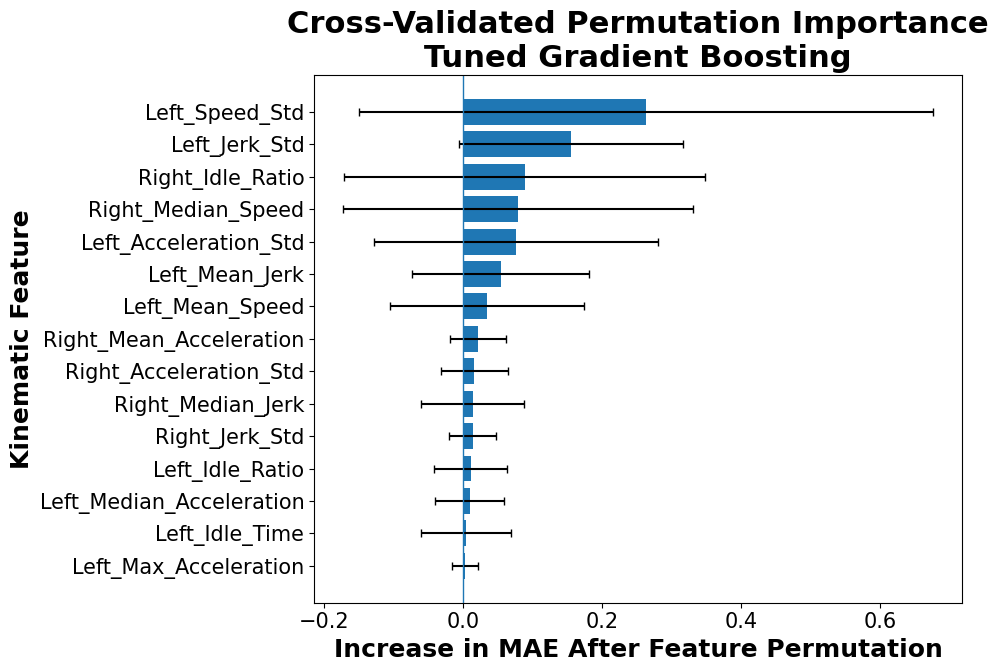

In [36]:
top_15_plot = (
    feature_importance_df
    .head(15)
    .sort_values(
        "Mean_Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_15_plot["Feature"],
    top_15_plot["Mean_Importance"],
    xerr=top_15_plot[
        "Std_Importance_Across_Subjects"
    ],
    capsize=3
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel(
    "Increase in MAE After Feature Permutation"
)

plt.ylabel("Kinematic Feature")

plt.title(
    "Cross-Validated Permutation Importance\n"
    "Tuned Gradient Boosting"
)

plt.tight_layout()

plt.savefig(
    RESULTS_PATH /
    "gradient_boosting_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

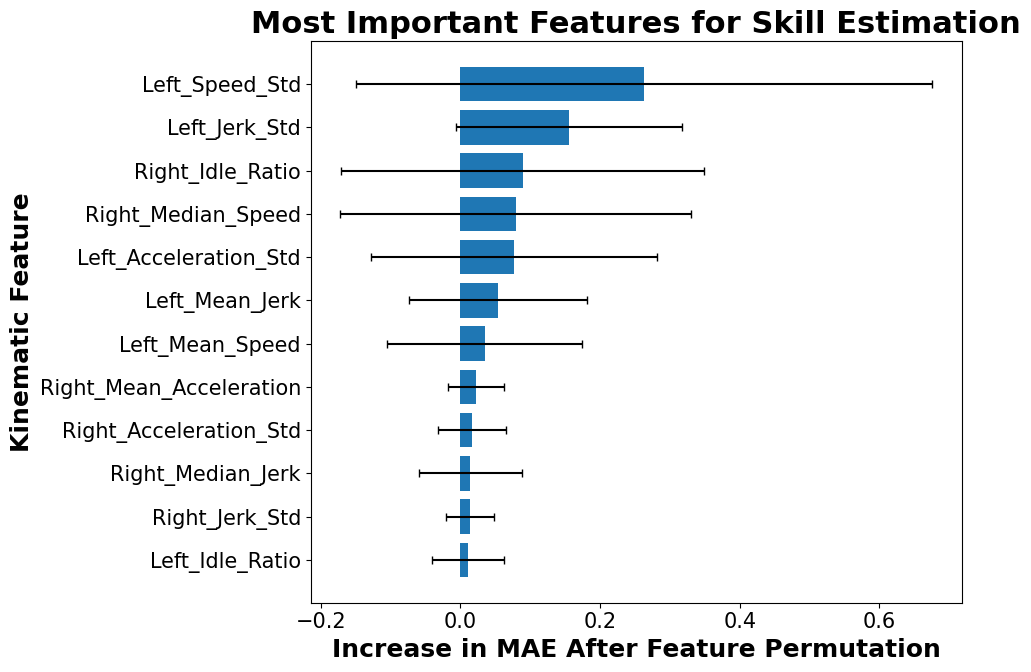

In [37]:
positive_importance_df = (
    feature_importance_df[
        feature_importance_df[
            "Mean_Importance"
        ] > 0
    ]
    .head(12)
    .sort_values(
        "Mean_Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    positive_importance_df["Feature"],
    positive_importance_df[
        "Mean_Importance"
    ],
    xerr=positive_importance_df[
        "Std_Importance_Across_Subjects"
    ],
    capsize=3
)

plt.xlabel(
    "Increase in MAE After Feature Permutation"
)

plt.ylabel("Kinematic Feature")

plt.title(
    "Most Important Features for Skill Estimation"
)

plt.tight_layout()

plt.savefig(
    RESULTS_PATH /
    "top_positive_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
feature_importance_df.to_csv(
    RESULTS_PATH /
    "gradient_boosting_feature_importance.csv",
    index=False
)

permutation_fold_df.to_csv(
    RESULTS_PATH /
    "gradient_boosting_feature_importance_by_subject.csv",
    index=False
)

baseline_importance_df.to_csv(
    RESULTS_PATH /
    "gradient_boosting_importance_baseline_mae.csv",
    index=False
)

print(
    "Feature importance results saved to:",
    RESULTS_PATH.resolve()
)

Feature importance results saved to: /Users/abdurrahmanoyediran/Library/CloudStorage/OneDrive-Personal(2)/Documents/02_Research/HUMANS_MOVE_RESEARCH/JIGSAWS DATA/results/modeling


In [39]:
feature_label_map = {
    "Left_Speed_Std": "Left Speed Variability",
    "Left_Jerk_Std": "Left Jerk Variability",
    "Right_Idle_Ratio": "Right Idle Ratio",
    "Right_Median_Speed": "Right Median Speed",
    "Left_Acceleration_Std": "Left Acceleration Variability",
    "Left_Mean_Jerk": "Left Mean Jerk",
    "Left_Mean_Speed": "Left Mean Speed"
}

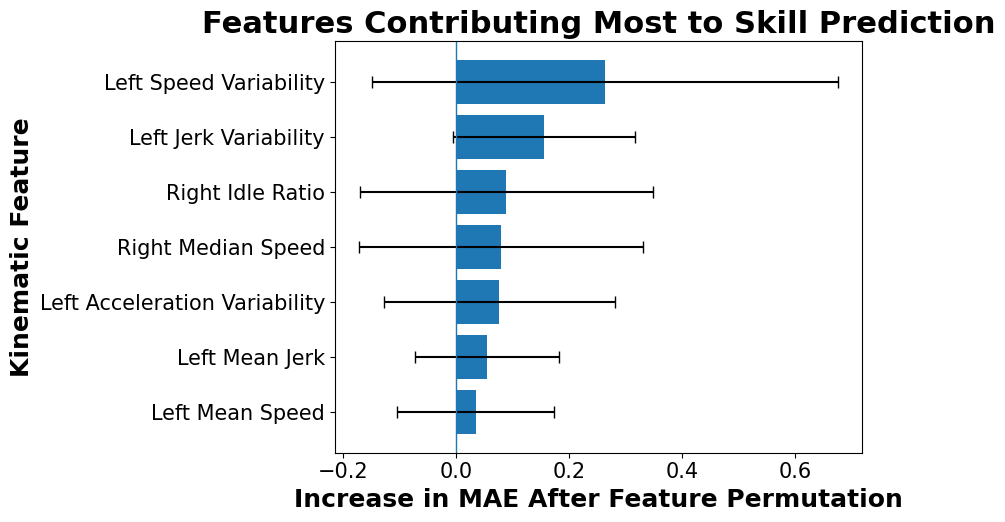

In [40]:
poster_features = (
    feature_importance_df
    .head(7)
    .copy()
)

feature_label_map = {
    "Left_Speed_Std": "Left Speed Variability",
    "Left_Jerk_Std": "Left Jerk Variability",
    "Right_Idle_Ratio": "Right Idle Ratio",
    "Right_Median_Speed": "Right Median Speed",
    "Left_Acceleration_Std": "Left Acceleration Variability",
    "Left_Mean_Jerk": "Left Mean Jerk",
    "Left_Mean_Speed": "Left Mean Speed"
}

poster_features["Readable_Feature"] = (
    poster_features["Feature"]
    .map(feature_label_map)
)

poster_features = poster_features.sort_values(
    "Mean_Importance",
    ascending=True
)

plt.figure(figsize=(9, 5.5))

plt.barh(
    poster_features["Readable_Feature"],
    poster_features["Mean_Importance"],
    xerr=poster_features[
        "Std_Importance_Across_Subjects"
    ],
    capsize=4
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel(
    "Increase in MAE After Feature Permutation"
)

plt.ylabel("Kinematic Feature")

plt.title(
    "Features Contributing Most to Skill Prediction"
)

plt.tight_layout()

plt.savefig(
    RESULTS_PATH /
    "poster_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
gradient_boosting_tuned.keys()

dict_keys(['overall', 'folds', 'predictions', 'parameters'])

In [42]:
best_predictions_df = gradient_boosting_tuned["predictions"].copy()

print(best_predictions_df.shape)
print(best_predictions_df.columns.tolist())

best_predictions_df.head()

(103, 10)
['Model', 'Outer_Fold', 'Trial_ID', 'Trial_Name', 'Task', 'Subject', 'Actual_GRS', 'Predicted_GRS', 'Error', 'Absolute_Error']


,Model,Outer_Fold,Trial_ID,Trial_Name,Task,Subject,Actual_GRS,Predicted_GRS,Error,Absolute_Error
0,Tuned Gradient Boosting,1,1,Knot_Tying_B001,Knot Tying,B,13,12.284459,-0.715541,0.715541
1,Tuned Gradient Boosting,1,2,Knot_Tying_B002,Knot Tying,B,9,13.207249,4.207249,4.207249
2,Tuned Gradient Boosting,1,3,Knot_Tying_B003,Knot Tying,B,11,13.334296,2.334296,2.334296
3,Tuned Gradient Boosting,1,4,Knot_Tying_B004,Knot Tying,B,8,15.152633,7.152633,7.152633
4,Tuned Gradient Boosting,1,37,Needle_Passing_B001,Needle Passing,B,8,14.451275,6.451275,6.451275


In [43]:
best_actual = best_predictions_df["Actual_GRS"]
best_predicted = best_predictions_df["Predicted_GRS"]

best_mae = mean_absolute_error(
    best_actual,
    best_predicted
)

best_rmse = np.sqrt(
    mean_squared_error(
        best_actual,
        best_predicted
    )
)

best_r2 = r2_score(
    best_actual,
    best_predicted
)

print(f"MAE: {best_mae:.3f}")
print(f"RMSE: {best_rmse:.3f}")
print(f"R²: {best_r2:.3f}")

MAE: 4.299
RMSE: 5.193
R²: 0.132


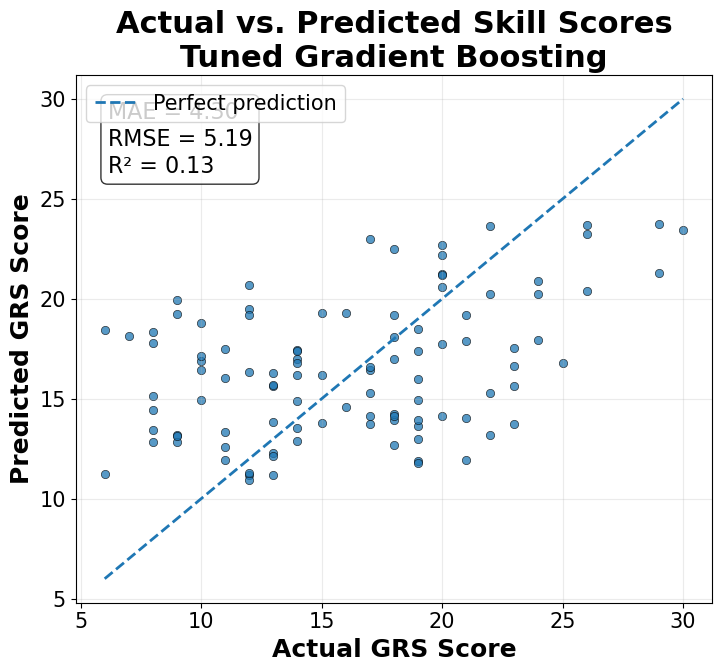

In [44]:
minimum_score = min(
    best_actual.min(),
    best_predicted.min()
)

maximum_score = max(
    best_actual.max(),
    best_predicted.max()
)

plt.figure(figsize=(7.5, 7))

plt.scatter(
    best_actual,
    best_predicted,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.5
)

plt.plot(
    [minimum_score, maximum_score],
    [minimum_score, maximum_score],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual GRS Score")
plt.ylabel("Predicted GRS Score")

plt.title(
    "Actual vs. Predicted Skill Scores\n"
    "Tuned Gradient Boosting"
)

metrics_text = (
    f"MAE = {best_mae:.2f}\n"
    f"RMSE = {best_rmse:.2f}\n"
    f"R² = {best_r2:.2f}"
)

plt.text(
    0.05,
    0.95,
    metrics_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.8
    }
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    RESULTS_PATH /
    "actual_vs_predicted_gradient_boosting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
best_predictions_df["Residual"] = (
    best_predictions_df["Actual_GRS"]
    - best_predictions_df["Predicted_GRS"]
)

best_predictions_df["Absolute_Error"] = (
    best_predictions_df["Residual"].abs()
)

best_predictions_df[
    [
        "Actual_GRS",
        "Predicted_GRS",
        "Residual",
        "Absolute_Error"
    ]
].head()

,Actual_GRS,Predicted_GRS,Residual,Absolute_Error
0,13,12.284459,0.715541,0.715541
1,9,13.207249,-4.207249,4.207249
2,11,13.334296,-2.334296,2.334296
3,8,15.152633,-7.152633,7.152633
4,8,14.451275,-6.451275,6.451275


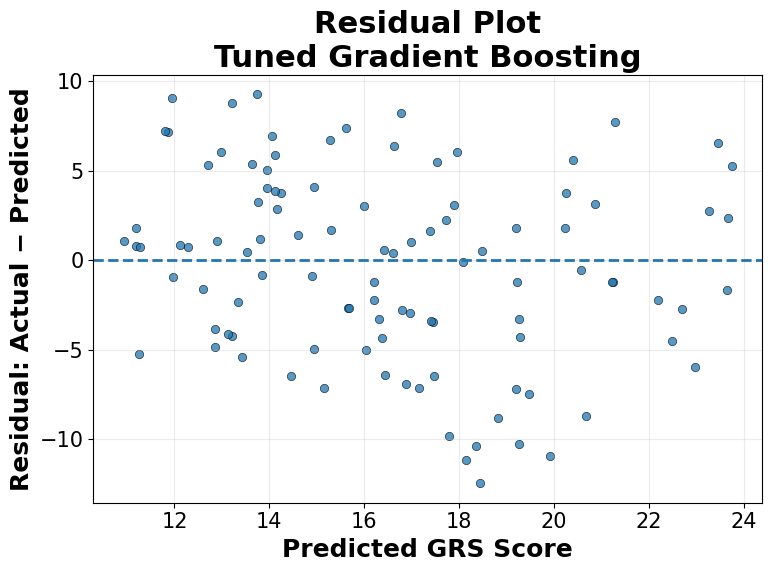

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(
    best_predictions_df["Predicted_GRS"],
    best_predictions_df["Residual"],
    alpha=0.75,
    edgecolors="black",
    linewidths=0.5
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted GRS Score")
plt.ylabel("Residual: Actual − Predicted")

plt.title(
    "Residual Plot\n"
    "Tuned Gradient Boosting"
)

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    RESULTS_PATH /
    "gradient_boosting_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

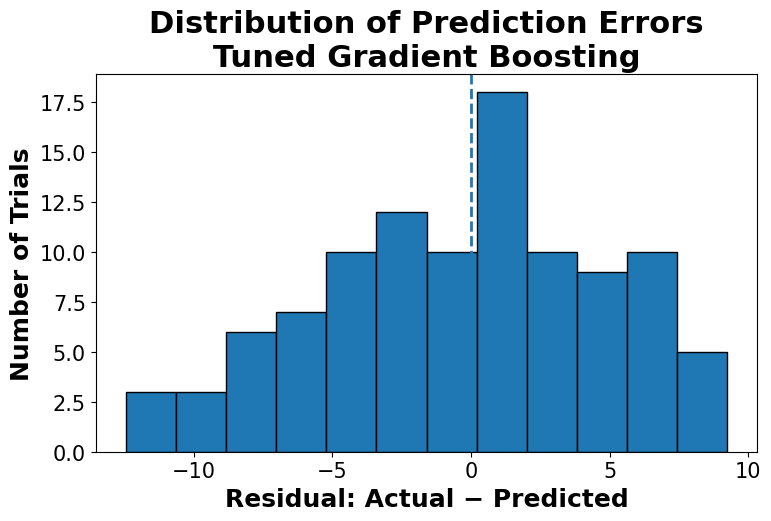

In [47]:
plt.figure(figsize=(8, 5.5))

plt.hist(
    best_predictions_df["Residual"],
    bins=12,
    edgecolor="black"
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual: Actual − Predicted")
plt.ylabel("Number of Trials")

plt.title(
    "Distribution of Prediction Errors\n"
    "Tuned Gradient Boosting"
)

plt.tight_layout()

plt.savefig(
    RESULTS_PATH /
    "gradient_boosting_residual_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
best_predictions_df["GRS_Group"] = pd.cut(
    best_predictions_df["Actual_GRS"],
    bins=[0, 12, 20, 30],
    labels=[
        "Lower GRS",
        "Middle GRS",
        "Higher GRS"
    ],
    include_lowest=True
)

skill_group_results_df = (
    best_predictions_df
    .groupby(
        "GRS_Group",
        observed=False
    )
    .agg(
        Number_of_Trials=("Actual_GRS", "size"),
        Mean_Actual_GRS=("Actual_GRS", "mean"),
        Mean_Predicted_GRS=("Predicted_GRS", "mean"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )
    .reset_index()
)

skill_group_results_df

,GRS_Group,Number_of_Trials,Mean_Actual_GRS,Mean_Predicted_GRS,MAE,Mean_Residual
0,Lower GRS,31,9.709677,15.578911,6.038395,-5.869234
1,Middle GRS,50,16.740000,16.164715,2.721218,0.575285
2,Higher GRS,22,23.954545,18.668757,5.435822,5.285788


In [49]:
best_predictions_df.to_csv(
    RESULTS_PATH /
    "best_model_predictions_with_residuals.csv",
    index=False
)

skill_group_results_df.to_csv(
    RESULTS_PATH /
    "prediction_performance_by_grs_group.csv",
    index=False
)

print("Prediction analysis saved.")

Prediction analysis saved.


In [50]:
feature_groups = {
    "Speed": [
        column for column in X.columns
        if "Speed" in column
    ],

    "Acceleration": [
        column for column in X.columns
        if "Acceleration" in column
    ],

    "Jerk": [
        column for column in X.columns
        if "Jerk" in column
    ],

    "Idle": [
        column for column in X.columns
        if "Idle" in column
    ],

    "Duration": [
        column for column in X.columns
        if column == "Duration_Seconds"
    ]
}

for group_name, columns in feature_groups.items():
    print(f"\n{group_name}: {len(columns)} features")
    print(columns)


Speed: 8 features
['Left_Mean_Speed', 'Left_Median_Speed', 'Left_Max_Speed', 'Left_Speed_Std', 'Right_Mean_Speed', 'Right_Median_Speed', 'Right_Max_Speed', 'Right_Speed_Std']

Acceleration: 8 features
['Left_Mean_Acceleration', 'Left_Median_Acceleration', 'Left_Max_Acceleration', 'Left_Acceleration_Std', 'Right_Mean_Acceleration', 'Right_Median_Acceleration', 'Right_Max_Acceleration', 'Right_Acceleration_Std']

Jerk: 8 features
['Left_Mean_Jerk', 'Left_Median_Jerk', 'Left_Max_Jerk', 'Left_Jerk_Std', 'Right_Mean_Jerk', 'Right_Median_Jerk', 'Right_Max_Jerk', 'Right_Jerk_Std']

Idle: 4 features
['Left_Idle_Ratio', 'Left_Idle_Time', 'Right_Idle_Ratio', 'Right_Idle_Time']

Duration: 1 features
['Duration_Seconds']


In [51]:
ablation_datasets = {
    "All Features": X.copy()
}

for group_name, columns_to_remove in feature_groups.items():
    ablation_datasets[f"Without {group_name}"] = (
        X.drop(columns=columns_to_remove)
    )

for condition_name, X_condition in ablation_datasets.items():
    print(
        f"{condition_name}: "
        f"{X_condition.shape[1]} predictors"
    )

All Features: 29 predictors
Without Speed: 21 predictors
Without Acceleration: 21 predictors
Without Jerk: 21 predictors
Without Idle: 25 predictors
Without Duration: 28 predictors


In [52]:
def evaluate_ablation_condition(
    condition_name,
    X_condition,
    y,
    groups,
    estimator,
    parameter_space,
    n_iter=15
):
    """
    Evaluate one feature-set condition using nested
    leave-one-subject-out cross-validation.
    """

    outer_cv = LeaveOneGroupOut()

    prediction_rows = []
    fold_rows = []

    print("=" * 70)
    print(f"Ablation condition: {condition_name}")
    print(
        f"Number of predictors: {X_condition.shape[1]}"
    )
    print("=" * 70)

    for outer_fold, (train_index, test_index) in enumerate(
        outer_cv.split(
            X_condition,
            y,
            groups=groups
        ),
        start=1
    ):
        X_train = X_condition.iloc[train_index]
        X_test = X_condition.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        groups_train = groups.iloc[train_index]
        test_subject = groups.iloc[test_index].unique()[0]

        inner_cv = LeaveOneGroupOut()

        search = RandomizedSearchCV(
            estimator=clone(estimator),
            param_distributions=parameter_space,
            n_iter=n_iter,
            scoring="neg_mean_absolute_error",
            cv=inner_cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True
        )

        search.fit(
            X_train,
            y_train,
            groups=groups_train
        )

        y_pred = search.best_estimator_.predict(X_test)

        fold_mae = mean_absolute_error(
            y_test,
            y_pred
        )

        fold_rmse = np.sqrt(
            mean_squared_error(
                y_test,
                y_pred
            )
        )

        fold_r2 = r2_score(
            y_test,
            y_pred
        )

        print(
            f"Fold {outer_fold}/8 | "
            f"Subject {test_subject} | "
            f"MAE = {fold_mae:.3f}"
        )

        fold_rows.append({
            "Condition": condition_name,
            "Outer_Fold": outer_fold,
            "Test_Subject": test_subject,
            "Number_of_Features": (
                X_condition.shape[1]
            ),
            "MAE": fold_mae,
            "RMSE": fold_rmse,
            "R2": fold_r2
        })

        for position, dataset_index in enumerate(
            test_index
        ):
            prediction_rows.append({
                "Condition": condition_name,
                "Outer_Fold": outer_fold,
                "Test_Subject": test_subject,
                "Dataset_Index": dataset_index,
                "Actual_GRS": y_test.iloc[position],
                "Predicted_GRS": y_pred[position]
            })

    predictions = pd.DataFrame(prediction_rows)
    folds = pd.DataFrame(fold_rows)

    overall = {
        "Condition": condition_name,
        "Number_of_Features": X_condition.shape[1],
        "MAE": mean_absolute_error(
            predictions["Actual_GRS"],
            predictions["Predicted_GRS"]
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                predictions["Actual_GRS"],
                predictions["Predicted_GRS"]
            )
        ),
        "R2": r2_score(
            predictions["Actual_GRS"],
            predictions["Predicted_GRS"]
        ),
        "Mean_Fold_MAE": folds["MAE"].mean(),
        "Std_Fold_MAE": folds["MAE"].std()
    }

    return {
        "overall": overall,
        "folds": folds,
        "predictions": predictions
    }

In [53]:
ablation_results = {}

ablation_results["All Features"] = (
    evaluate_ablation_condition(
        condition_name="All Features",
        X_condition=ablation_datasets[
            "All Features"
        ],
        y=y,
        groups=groups,
        estimator=models_to_tune[
            "Gradient Boosting"
        ],
        parameter_space=parameter_spaces[
            "Gradient Boosting"
        ],
        n_iter=15
    )
)

Ablation condition: All Features
Number of predictors: 29
Fold 1/8 | Subject B | MAE = 3.855
Fold 2/8 | Subject C | MAE = 4.910
Fold 3/8 | Subject D | MAE = 3.380
Fold 4/8 | Subject E | MAE = 4.534
Fold 5/8 | Subject F | MAE = 4.629
Fold 6/8 | Subject G | MAE = 4.383
Fold 7/8 | Subject H | MAE = 4.073
Fold 8/8 | Subject I | MAE = 4.629


In [54]:
ablation_results["Without Jerk"] = (
    evaluate_ablation_condition(
        condition_name="Without Jerk",
        X_condition=ablation_datasets[
            "Without Jerk"
        ],
        y=y,
        groups=groups,
        estimator=models_to_tune[
            "Gradient Boosting"
        ],
        parameter_space=parameter_spaces[
            "Gradient Boosting"
        ],
        n_iter=15
    )
)

Ablation condition: Without Jerk
Number of predictors: 21
Fold 1/8 | Subject B | MAE = 3.578
Fold 2/8 | Subject C | MAE = 4.744
Fold 3/8 | Subject D | MAE = 2.612
Fold 4/8 | Subject E | MAE = 4.467
Fold 5/8 | Subject F | MAE = 5.755
Fold 6/8 | Subject G | MAE = 5.285
Fold 7/8 | Subject H | MAE = 4.531
Fold 8/8 | Subject I | MAE = 4.990


In [55]:
ablation_results["Without Speed"] = (
    evaluate_ablation_condition(
        condition_name="Without Speed",
        X_condition=ablation_datasets[
            "Without Speed"
        ],
        y=y,
        groups=groups,
        estimator=models_to_tune[
            "Gradient Boosting"
        ],
        parameter_space=parameter_spaces[
            "Gradient Boosting"
        ],
        n_iter=15
    )
)

Ablation condition: Without Speed
Number of predictors: 21
Fold 1/8 | Subject B | MAE = 3.648
Fold 2/8 | Subject C | MAE = 6.877
Fold 3/8 | Subject D | MAE = 2.729
Fold 4/8 | Subject E | MAE = 4.003
Fold 5/8 | Subject F | MAE = 6.509
Fold 6/8 | Subject G | MAE = 3.173
Fold 7/8 | Subject H | MAE = 4.847
Fold 8/8 | Subject I | MAE = 4.963


In [56]:
ablation_results["Without Acceleration"] = (
    evaluate_ablation_condition(
        condition_name="Without Acceleration",
        X_condition=ablation_datasets[
            "Without Acceleration"
        ],
        y=y,
        groups=groups,
        estimator=models_to_tune[
            "Gradient Boosting"
        ],
        parameter_space=parameter_spaces[
            "Gradient Boosting"
        ],
        n_iter=15
    )
)

Ablation condition: Without Acceleration
Number of predictors: 21
Fold 1/8 | Subject B | MAE = 4.261
Fold 2/8 | Subject C | MAE = 6.174
Fold 3/8 | Subject D | MAE = 3.226
Fold 4/8 | Subject E | MAE = 4.024
Fold 5/8 | Subject F | MAE = 5.450
Fold 6/8 | Subject G | MAE = 4.588
Fold 7/8 | Subject H | MAE = 4.115
Fold 8/8 | Subject I | MAE = 4.794


In [57]:
ablation_results["Without Idle"] = (
    evaluate_ablation_condition(
        condition_name="Without Idle",
        X_condition=ablation_datasets[
            "Without Idle"
        ],
        y=y,
        groups=groups,
        estimator=models_to_tune[
            "Gradient Boosting"
        ],
        parameter_space=parameter_spaces[
            "Gradient Boosting"
        ],
        n_iter=15
    )
)

Ablation condition: Without Idle
Number of predictors: 25
Fold 1/8 | Subject B | MAE = 4.198
Fold 2/8 | Subject C | MAE = 5.603
Fold 3/8 | Subject D | MAE = 3.398
Fold 4/8 | Subject E | MAE = 4.709
Fold 5/8 | Subject F | MAE = 5.812
Fold 6/8 | Subject G | MAE = 4.498
Fold 7/8 | Subject H | MAE = 5.029
Fold 8/8 | Subject I | MAE = 5.391


In [58]:
ablation_results["Without Duration"] = (
    evaluate_ablation_condition(
        condition_name="Without Duration",
        X_condition=ablation_datasets[
            "Without Duration"
        ],
        y=y,
        groups=groups,
        estimator=models_to_tune[
            "Gradient Boosting"
        ],
        parameter_space=parameter_spaces[
            "Gradient Boosting"
        ],
        n_iter=15
    )
)

Ablation condition: Without Duration
Number of predictors: 28
Fold 1/8 | Subject B | MAE = 3.835
Fold 2/8 | Subject C | MAE = 6.294
Fold 3/8 | Subject D | MAE = 3.095
Fold 4/8 | Subject E | MAE = 4.256
Fold 5/8 | Subject F | MAE = 5.401
Fold 6/8 | Subject G | MAE = 4.663
Fold 7/8 | Subject H | MAE = 3.973
Fold 8/8 | Subject I | MAE = 4.861


In [59]:
ablation_summary_df = pd.DataFrame([
    result["overall"]
    for result in ablation_results.values()
])

all_features_mae = ablation_summary_df.loc[
    ablation_summary_df["Condition"]
    == "All Features",
    "MAE"
].iloc[0]

ablation_summary_df[
    "MAE_Change_From_All_Features"
] = (
    ablation_summary_df["MAE"]
    - all_features_mae
)

ablation_summary_df[
    "Percent_MAE_Change"
] = (
    ablation_summary_df[
        "MAE_Change_From_All_Features"
    ]
    / all_features_mae
    * 100
)

ablation_summary_df = (
    ablation_summary_df
    .sort_values("MAE")
    .reset_index(drop=True)
)

ablation_summary_df

,Condition,Number_of_Features,MAE,RMSE,R2,Mean_Fold_MAE,Std_Fold_MAE,MAE_Change_From_All_Features,Percent_MAE_Change
0,All Features,29,4.299410,5.193325,0.131936,4.298972,0.499414,0.000000,0.000000
1,Without Jerk,21,4.439193,5.393680,0.063665,4.495230,0.993284,0.139783,3.251216
2,Without Duration,28,4.563441,5.580439,-0.002300,4.547215,0.994349,0.264031,6.141094
3,Without Acceleration,21,4.591670,5.570107,0.001408,4.579071,0.910655,0.292260,6.797682
4,Without Speed,21,4.630072,5.804513,-0.084408,4.593676,1.503384,0.330662,7.690865
5,Without Idle,25,4.819607,5.869548,-0.108843,4.829710,0.801108,0.520197,12.099256


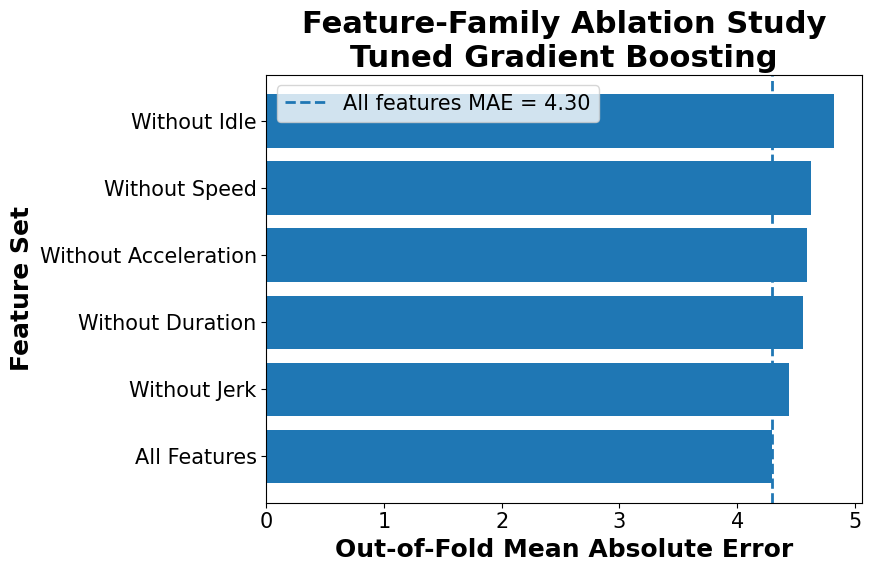

In [60]:
ablation_plot_df = (
    ablation_summary_df
    .sort_values(
        "MAE",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    ablation_plot_df["Condition"],
    ablation_plot_df["MAE"]
)

plt.axvline(
    x=all_features_mae,
    linestyle="--",
    linewidth=2,
    label=(
        f"All features MAE = "
        f"{all_features_mae:.2f}"
    )
)

plt.xlabel("Out-of-Fold Mean Absolute Error")
plt.ylabel("Feature Set")

plt.title(
    "Feature-Family Ablation Study\n"
    "Tuned Gradient Boosting"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS_PATH /
    "feature_family_ablation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

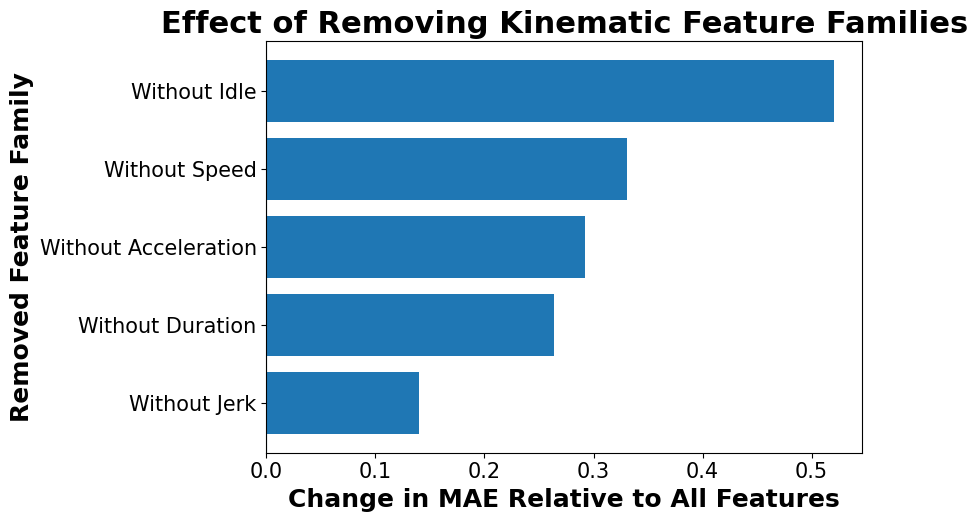

In [61]:
change_plot_df = (
    ablation_summary_df[
        ablation_summary_df["Condition"]
        != "All Features"
    ]
    .sort_values(
        "MAE_Change_From_All_Features"
    )
)

plt.figure(figsize=(9, 5.5))

plt.barh(
    change_plot_df["Condition"],
    change_plot_df[
        "MAE_Change_From_All_Features"
    ]
)

plt.axvline(
    x=0,
    linewidth=1.5
)

plt.xlabel(
    "Change in MAE Relative to All Features"
)

plt.ylabel("Removed Feature Family")

plt.title(
    "Effect of Removing Kinematic Feature Families"
)

plt.tight_layout()

plt.savefig(
    RESULTS_PATH /
    "feature_family_ablation_change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
ablation_summary_df.to_csv(
    RESULTS_PATH /
    "feature_family_ablation_summary.csv",
    index=False
)

for condition_name, result in (
    ablation_results.items()
):
    safe_name = (
        condition_name
        .lower()
        .replace(" ", "_")
    )

    result["folds"].to_csv(
        RESULTS_PATH /
        f"ablation_{safe_name}_folds.csv",
        index=False
    )

    result["predictions"].to_csv(
        RESULTS_PATH /
        f"ablation_{safe_name}_predictions.csv",
        index=False
    )

print("Ablation results saved.")

Ablation results saved.


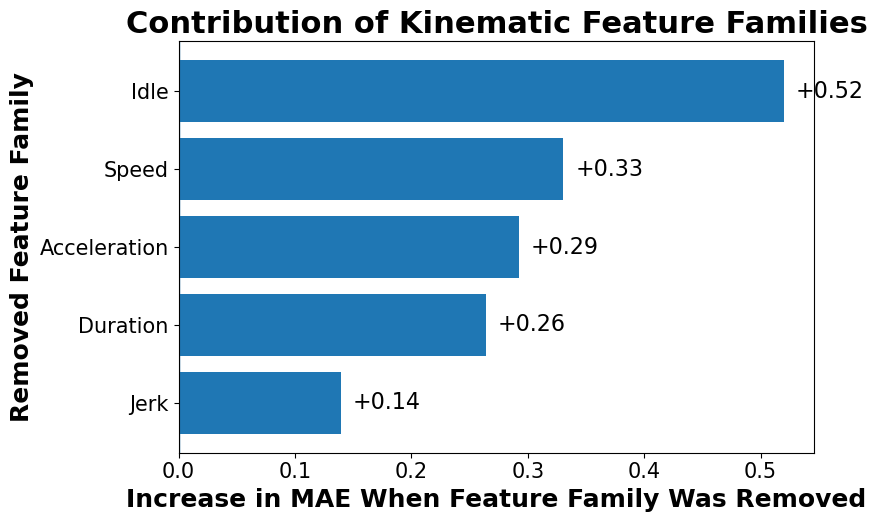

In [63]:
ablation_contribution_df = (
    ablation_summary_df[
        ablation_summary_df["Condition"] != "All Features"
    ]
    .copy()
)

ablation_contribution_df["Feature_Family"] = (
    ablation_contribution_df["Condition"]
    .str.replace("Without ", "", regex=False)
)

ablation_contribution_df = (
    ablation_contribution_df
    .sort_values(
        "MAE_Change_From_All_Features",
        ascending=True
    )
)

plt.figure(figsize=(9, 5.5))

bars = plt.barh(
    ablation_contribution_df["Feature_Family"],
    ablation_contribution_df[
        "MAE_Change_From_All_Features"
    ]
)

plt.axvline(x=0, linewidth=1)

plt.xlabel(
    "Increase in MAE When Feature Family Was Removed"
)

plt.ylabel("Removed Feature Family")

plt.title(
    "Contribution of Kinematic Feature Families"
)

for bar, value in zip(
    bars,
    ablation_contribution_df[
        "MAE_Change_From_All_Features"
    ]
):
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"+{value:.2f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    RESULTS_PATH /
    "poster_feature_family_ablation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
gradient_boosting_tuned["predictions"].columns

Index(['Model', 'Outer_Fold', 'Trial_ID', 'Trial_Name', 'Task', 'Subject',
       'Actual_GRS', 'Predicted_GRS', 'Error', 'Absolute_Error'],
      dtype='object')

In [65]:
gradient_boosting_tuned["predictions"].head()

,Model,Outer_Fold,Trial_ID,Trial_Name,Task,Subject,Actual_GRS,Predicted_GRS,Error,Absolute_Error
0,Tuned Gradient Boosting,1,1,Knot_Tying_B001,Knot Tying,B,13,12.284459,-0.715541,0.715541
1,Tuned Gradient Boosting,1,2,Knot_Tying_B002,Knot Tying,B,9,13.207249,4.207249,4.207249
2,Tuned Gradient Boosting,1,3,Knot_Tying_B003,Knot Tying,B,11,13.334296,2.334296,2.334296
3,Tuned Gradient Boosting,1,4,Knot_Tying_B004,Knot Tying,B,8,15.152633,7.152633,7.152633
4,Tuned Gradient Boosting,1,37,Needle_Passing_B001,Needle Passing,B,8,14.451275,6.451275,6.451275


In [66]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

prediction_df = gradient_boosting_tuned["predictions"].copy()

task_results = []

for task, group in prediction_df.groupby("Task"):

    task_results.append({

        "Task": task,
        "Trials": len(group),

        "MAE": mean_absolute_error(
            group["Actual_GRS"],
            group["Predicted_GRS"]
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                group["Actual_GRS"],
                group["Predicted_GRS"]
            )
        ),

        "R2": r2_score(
            group["Actual_GRS"],
            group["Predicted_GRS"]
        ),

        "Mean_Error": group["Error"].mean()
    })

task_results_df = (
    pd.DataFrame(task_results)
      .sort_values("MAE")
      .reset_index(drop=True)
)

task_results_df

,Task,Trials,MAE,RMSE,R2,Mean_Error
0,Suturing,39,4.166299,4.880193,0.161973,-1.794391
1,Knot Tying,36,4.201250,5.110790,-0.030212,1.831170
2,Needle Passing,28,4.611022,5.697157,-0.447813,1.462635


In [67]:
subject_results = []

for subject, group in prediction_df.groupby("Subject"):

    subject_results.append({

        "Subject": subject,

        "Trials": len(group),

        "MAE": mean_absolute_error(
            group["Actual_GRS"],
            group["Predicted_GRS"]
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                group["Actual_GRS"],
                group["Predicted_GRS"]
            )
        ),

        "Mean_Error": group["Error"].mean()

    })

subject_results_df = (
    pd.DataFrame(subject_results)
      .sort_values("MAE")
      .reset_index(drop=True)
)

subject_results_df

,Subject,Trials,MAE,RMSE,Mean_Error
0,D,15,3.380038,4.549428,3.056484
1,B,13,3.854551,4.818986,3.297543
2,H,10,4.073413,4.704075,-3.394132
3,G,10,4.382532,5.226541,2.545994
4,E,14,4.533626,5.132308,-4.412982
5,F,13,4.628592,5.195043,-1.964982
6,I,13,4.628857,5.752282,-0.497465
7,C,15,4.910163,5.895749,3.363618


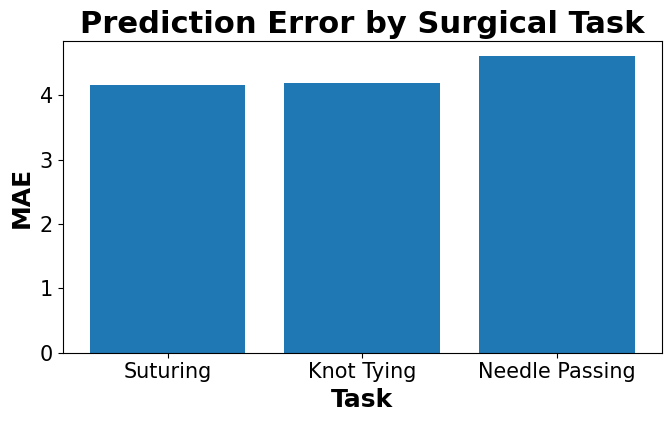

In [68]:
plt.figure(figsize=(7,4.5))

plt.bar(
    task_results_df["Task"],
    task_results_df["MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Task")

plt.title(
    "Prediction Error by Surgical Task"
)

plt.tight_layout()

plt.savefig(
    RESULTS_PATH / "task_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

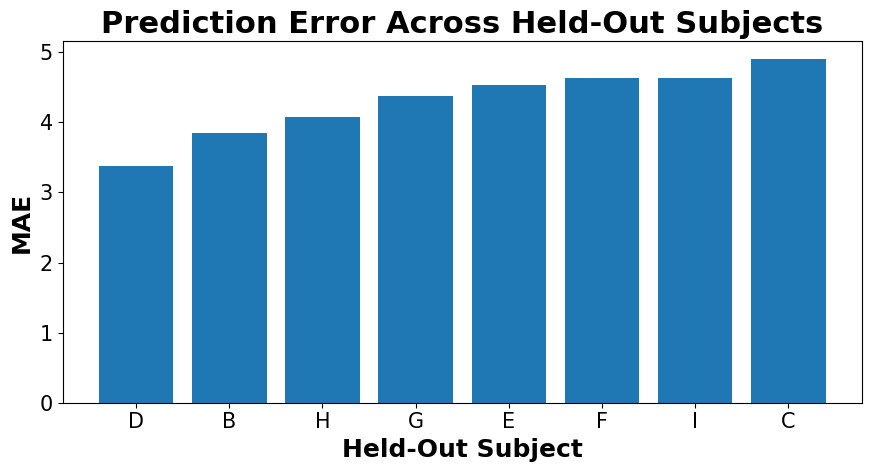

In [69]:
plt.figure(figsize=(9,5))

subject_plot = subject_results_df.sort_values("MAE")

plt.bar(
    subject_plot["Subject"],
    subject_plot["MAE"]
)

plt.xlabel("Held-Out Subject")

plt.ylabel("MAE")

plt.title(
    "Prediction Error Across Held-Out Subjects"
)

plt.tight_layout()

plt.savefig(
    RESULTS_PATH / "subject_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

prediction_df = gradient_boosting_tuned["predictions"].copy()

task_results = []

for task, group in prediction_df.groupby("Task"):

    task_results.append({

        "Task": task,

        "Trials": len(group),

        "MAE": mean_absolute_error(
            group["Actual_GRS"],
            group["Predicted_GRS"]
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                group["Actual_GRS"],
                group["Predicted_GRS"]
            )
        ),

        "R2": r2_score(
            group["Actual_GRS"],
            group["Predicted_GRS"]
        ),

        "Mean_Error": group["Error"].mean(),

        "Std_Error": group["Error"].std()

    })

task_results_df = (
    pd.DataFrame(task_results)
      .sort_values("MAE")
      .reset_index(drop=True)
)

task_results_df

,Task,Trials,MAE,RMSE,R2,Mean_Error,Std_Error
0,Suturing,39,4.166299,4.880193,0.161973,-1.794391,4.597658
1,Knot Tying,36,4.201250,5.110790,-0.030212,1.831170,4.839160
2,Needle Passing,28,4.611022,5.697157,-0.447813,1.462635,5.607246


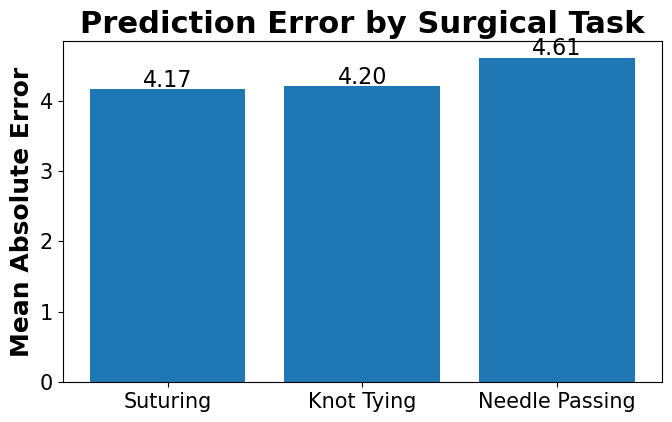

In [71]:
task_plot = task_results_df.sort_values("MAE")

plt.figure(figsize=(7,4.5))

bars = plt.bar(
    task_plot["Task"],
    task_plot["MAE"]
)

plt.ylabel("Mean Absolute Error")

plt.title(
    "Prediction Error by Surgical Task"
)

for bar in bars:

    plt.text(
        bar.get_width()/2 + bar.get_x(),
        bar.get_height()+0.03,
        f"{bar.get_height():.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    RESULTS_PATH / "task_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 800x500 with 0 Axes>

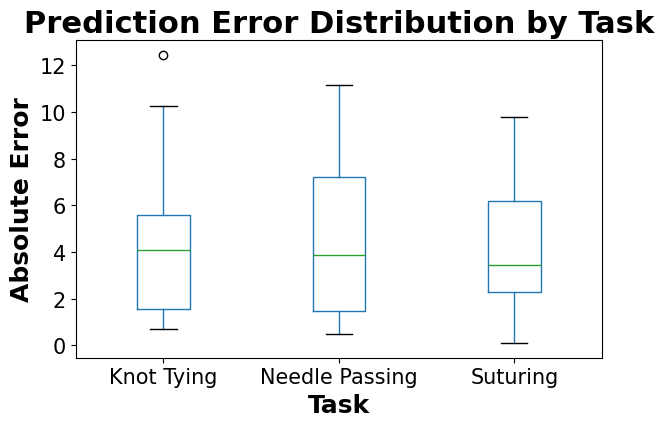

In [72]:
plt.figure(figsize=(8,5))

prediction_df.boxplot(
    column="Absolute_Error",
    by="Task",
    grid=False
)

plt.suptitle("")

plt.title(
    "Prediction Error Distribution by Task"
)

plt.ylabel("Absolute Error")

plt.xlabel("Task")

plt.tight_layout()

plt.savefig(
    RESULTS_PATH / "task_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
baseline_comparison_df = complete_model_comparison_df[
    complete_model_comparison_df["Model"].isin([
        "Dummy Regressor",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ])
].copy()

baseline_comparison_df = (
    baseline_comparison_df
    .sort_values("MAE")
    .reset_index(drop=True)
)

baseline_comparison_df

,Model,MAE,RMSE,R2,Mean_Error,Median_Absolute_Error,Version
0,Tuned Gradient Boosting,4.299410,5.193325,0.131936,0.358200,3.843505,Nested Tuned
1,Gradient Boosting,4.749647,5.975334,-0.149173,0.224468,3.547058,Untuned
2,Dummy Regressor,4.907240,5.786230,-0.077587,0.001153,4.150538,Untuned


In [74]:
dummy_mae = baseline_comparison_df.loc[
    baseline_comparison_df["Model"] == "Dummy Regressor",
    "MAE"
].iloc[0]

baseline_comparison_df["Improvement_vs_Dummy"] = (
    dummy_mae - baseline_comparison_df["MAE"]
)

baseline_comparison_df["Percent_Improvement"] = (
    baseline_comparison_df["Improvement_vs_Dummy"]
    / dummy_mae
    * 100
)

baseline_comparison_df

,Model,MAE,RMSE,R2,Mean_Error,Median_Absolute_Error,Version,Improvement_vs_Dummy,Percent_Improvement
0,Tuned Gradient Boosting,4.299410,5.193325,0.131936,0.358200,3.843505,Nested Tuned,0.607830,12.386385
1,Gradient Boosting,4.749647,5.975334,-0.149173,0.224468,3.547058,Untuned,0.157593,3.211432
2,Dummy Regressor,4.907240,5.786230,-0.077587,0.001153,4.150538,Untuned,0.000000,0.000000


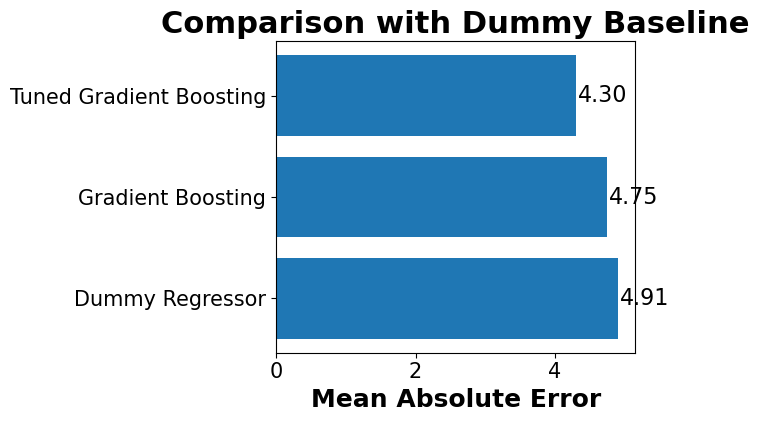

In [75]:
plot_df = (
    baseline_comparison_df
    .sort_values("MAE", ascending=False)
)

plt.figure(figsize=(7,4.5))

bars = plt.barh(
    plot_df["Model"],
    plot_df["MAE"]
)

for bar in bars:

    plt.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center"
    )

plt.xlabel("Mean Absolute Error")

plt.title(
    "Comparison with Dummy Baseline"
)

plt.tight_layout()

plt.savefig(
    RESULTS_PATH / "dummy_baseline_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
best_model = baseline_comparison_df.iloc[0]

print(f"Best model: {best_model['Model']}")
print(f"MAE: {best_model['MAE']:.3f}")
print(f"Improvement over Dummy: {best_model['Improvement_vs_Dummy']:.3f}")
print(f"Percent improvement: {best_model['Percent_Improvement']:.1f}%")

Best model: Tuned Gradient Boosting
MAE: 4.299
Improvement over Dummy: 0.608
Percent improvement: 12.4%
